In [4]:
import shutil
import os

destination_dir = '/kaggle/input/datasets/trankimhuu/myfashionmnist'
source_dir = '/kaggle/working'

if os.path.exists(destination_dir):
    !cp -r {destination_dir}/* {source_dir}
    !ls
    print('Setup thành công')
else:
    print('Sai nguồn rồi!')

t10k-images-idx3-ubyte	train-images-idx3-ubyte
t10k-labels-idx1-ubyte	train-labels-idx1-ubyte
Setup thành công


In [22]:
import numpy as np
import os
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
import logging
logging.getLogger("tensorflow").setLevel(logging.ERROR)
from sklearn.model_selection import train_test_split

In [23]:
# 1. Hàm đọc dữ liệu từ file binary (IDX format)
def load_mnist_data(path, kind='train'):
    labels_path = os.path.join(path, f'{kind}-labels-idx1-ubyte')
    images_path = os.path.join(path, f'{kind}-images-idx3-ubyte')

    with open(labels_path, 'rb') as lbpath:
        # Offset 8 byte cho file label
        labels = np.frombuffer(lbpath.read(), dtype=np.uint8, offset=8)

    with open(images_path, 'rb') as imgpath:
        # Offset 16 byte cho file image, sau đó reshape về 28x28
        images = np.frombuffer(imgpath.read(), dtype=np.uint8, offset=16).reshape(len(labels), 28, 28, 1)

    return images, labels

In [24]:
# 2. Load dữ liệu
path_to_data = '/kaggle/working/'
X_train_raw, y_train_raw = load_mnist_data(path_to_data, kind='train')
X_test, y_test = load_mnist_data(path_to_data, kind='t10k')

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw, 
    test_size=1/6, 
    random_state=42, 
    stratify=y_train_raw
)

# 3. Tính Mean và Std của tập Train 
X_train_f = X_train.astype('float32')
mean = np.mean(X_train)
std = np.std(X_train)

print(f"Mean của tập Train: {mean:.4f}")
print(f"Std của tập Train: {std:.4f}")

# 4. Thực hiện Standardization: (x - mean) / std
X_train_std = (X_train - mean) / (std + 1e-7) # Thêm 1 số cực nhỏ để tránh chia cho 0
X_val_std = (X_val.astype('float32') - mean) / (std + 1e-7)
X_test_std = (X_test.astype('float32') - mean) / (std + 1e-7)

Mean của tập Train: 73.0003
Std của tập Train: 90.0623


In [25]:
print(X_train_std.shape)
print(X_val_std.shape)
print(X_test_std.shape)

(50000, 28, 28, 1)
(10000, 28, 28, 1)
(10000, 28, 28, 1)


In [26]:
# 3. Định nghĩa Residual Block cho ResNet
def resnet_block(x, filters, strides=1):
    shortcut = x

    reg = regularizers.l2(1e-4)
    
    x = layers.Conv2D(filters, 3, strides=strides, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    x = layers.Conv2D(filters, 3, strides=1, padding='same', kernel_regularizer=reg)(x)
    x = layers.BatchNormalization()(x)
    
    if strides != 1 or shortcut.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding='same', kernel_regularizer=reg)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)
        
    x = layers.Add()([x, shortcut])
    x = layers.Activation('relu')(x)
    return x

In [27]:
def build_final_resnet():
    inputs = layers.Input(shape=(28, 28, 1))
    
    # --- BƯỚC 1: DATA AUGMENTATION ---
    x = layers.RandomFlip("horizontal")(inputs)
    x = layers.RandomRotation(0.05)(x)
    x = layers.RandomZoom(0.05)(x)

    # --- BƯỚC 2: KIẾN TRÚC RESNET-18 CHUẨN ---
    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    
    # Stage 1 (28x28)
    x = resnet_block(x, 64); x = resnet_block(x, 64)
    # Stage 2 (14x14)
    x = resnet_block(x, 128, strides=2); x = resnet_block(x, 128)
    # Stage 3 (7x7)
    x = resnet_block(x, 256, strides=2); x = resnet_block(x, 256)
    # Stage 4 (4x4)
    x = resnet_block(x, 512, strides=2); x = resnet_block(x, 512)
    
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(10, activation='softmax')(x)
    
    return models.Model(inputs, outputs)

In [28]:
model = build_final_resnet()

In [33]:
# Đường dẫn lưu file trên Kaggle working
model_path = 'best_fashion_resnet.keras'
params_path = 'norm_params.npy'

# Khởi tạo Callback ModelCheckpoint
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_path,
    monitor='val_accuracy', # Theo dõi độ chính xác tập validation
    save_best_only=True,    # Chỉ lưu nếu kết quả tốt hơn phiên bản trước
    mode='max',             # Tìm giá trị lớn nhất
    verbose=1
)

lr_reducer = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6, verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=7, restore_best_weights=True
)

np.save(params_path, [mean, std])
print(f"--- Đã lưu Mean ({mean:.4f}) và Std ({std:.4f}) vào {params_path} ---")

--- Đã lưu Mean (73.0003) và Std (90.0623) vào norm_params.npy ---


In [34]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    X_train_std, y_train, 
    epochs=50, 
    batch_size=128,
    validation_data=(X_val_std, y_val),
    callbacks=[checkpoint_cb, lr_reducer, early_stop]
)

Epoch 1/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - accuracy: 0.9079 - loss: 0.3882
Epoch 1: val_accuracy improved from -inf to 0.90350, saving model to best_fashion_resnet.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 76s 161ms/step - accuracy: 0.9079 - loss: 0.3882 - val_accuracy: 0.9035 - val_loss: 0.4250 - learning_rate: 0.0010
Epoch 2/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9108 - loss: 0.3914
Epoch 2: val_accuracy did not improve from 0.90350
391/391 ━━━━━━━━━━━━━━━━━━━━ 60s 154ms/step - accuracy: 0.9108 - loss: 0.3915 - val_accuracy: 0.8941 - val_loss: 0.4505 - learning_rate: 0.0010
Epoch 3/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accuracy: 0.9140 - loss: 0.3895
Epoch 3: val_accuracy improved from 0.90350 to 0.91370, saving model to best_fashion_resnet.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 61s 156ms/step - accuracy: 0.9140 - loss: 0.3895 - val_accuracy: 0.9137 - val_loss: 0.3837 - learning_rate: 0.0010
Epoch 4/50
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step - accu

In [35]:
print("\n--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---")
test_loss, test_acc = model.evaluate(X_test_std, y_test, verbose=0)

print(f"Loss trên tập Test: {test_loss:.4f}")
print(f"Độ chính xác trên tập Test: {test_acc*100:.2f}%")


--- ĐÁNH GIÁ CUỐI CÙNG TRÊN TẬP TEST ---
Loss trên tập Test: 0.2639
Độ chính xác trên tập Test: 93.80%


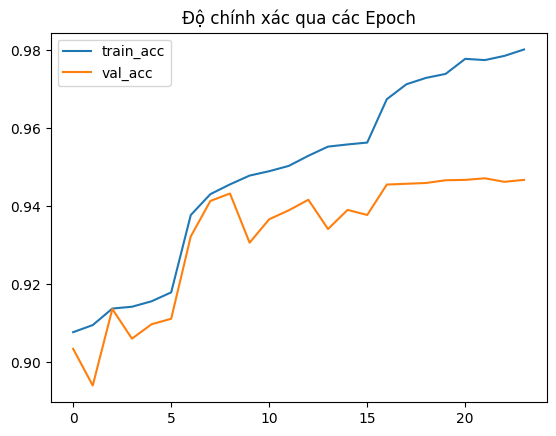

In [36]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Độ chính xác qua các Epoch')
plt.legend()
plt.show()

In [37]:
!ls -l /kaggle/working/

total 185016
-rw-r--r-- 1 root root 134490533 Mar 22 09:28 best_fashion_resnet.keras
-rw-r--r-- 1 root root       144 Mar 22 09:05 norm_params.npy
-rw-r--r-- 1 root root   7840016 Mar 22 08:33 t10k-images-idx3-ubyte
-rw-r--r-- 1 root root     10008 Mar 22 08:33 t10k-labels-idx1-ubyte
-rw-r--r-- 1 root root  47040016 Mar 22 08:33 train-images-idx3-ubyte
-rw-r--r-- 1 root root     60008 Mar 22 08:33 train-labels-idx1-ubyte


In [38]:
from IPython.display import FileLink

# Tạo link tải file mô hình
display(FileLink('best_fashion_resnet.keras'))

# Tạo link tải file tham số chuẩn hóa
display(FileLink('norm_params.npy'))

/kaggle/working/best_fashion_resnet.keras

/kaggle/working/norm_params.npy